In [3]:
#librarys used
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
user_activity = pd.read_csv('da_fitly_user_activity.csv')
customer_support = pd.read_csv('da_fitly_customer_support.csv')
account_info = pd.read_csv('da_fitly_account_info.csv')

print("Dataset Shapes:")
print(f"User Activity: {user_activity.shape}")
print(f"Customer Support: {customer_support.shape}")
print(f"Account Info: {account_info.shape}")
print("-"*30)
print("User Activity:")
print(user_activity.head())
print("\nCustomer Support:")
print(customer_support.head())
print("\nAccount Info:")
print(account_info.head())

Dataset Shapes:
User Activity: (445, 3)
Customer Support: (918, 7)
Account Info: (400, 6)
------------------------------
User Activity:
                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout

Customer Support:
                  ticket_time  user_id  ... state                          comments
0  2025-06-13 05:55:17.154573    10125  ...     1                               NaN
1  2025-08-06 13:21:54.539551    10109  ...     0                               NaN
2  2025-08-22 12:39:35.718663    10149  ...     0  Erase my data from your systems.
3  2025-06-07 02:49:46.986055    10268  ...     1                               NaN
4  2025-07-25 00:24:38.945079    10041  ...     1                               NaN

[5 rows x 7 colu

2.1 User Activity Data Validation

In [4]:
# Check user activity data
print("User Activity Data Info:")
print(user_activity.info())
print("-"*30)
print("\nMissing values in user_activity:")
print(user_activity.isnull().sum())
print("-"*30)
print("\nUnique event types:")
print(user_activity['event_type'].value_counts())
print("-"*30)
print("\nDate range:")
print(f"Earliest: {user_activity['event_time'].min()}")
print(f"Latest: {user_activity['event_time'].max()}")
print("-"*30)
# Convert event_time to datetime
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])
user_activity['event_date'] = user_activity['event_time'].dt.date
user_activity['event_month'] = user_activity['event_time'].dt.to_period('M')

print(f"\nTotal unique users in activity data: {user_activity['user_id'].nunique()}")

User Activity Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB
None
------------------------------

Missing values in user_activity:
event_time    0
user_id       0
event_type    0
dtype: int64
------------------------------

Unique event types:
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: event_type, dtype: int64
------------------------------

Date range:
Earliest: 2025-06-05 10:14:53.039663
Latest: 2025-12-01 21:12:13.342817
------------------------------

Total unique users in activity data: 246


2.2 Customer Support Data Validation

In [5]:
# Check customer support data
print("\nCustomer Support Data Info:")
print(customer_support.info())
print("\nMissing values in customer_support:")
print(customer_support.isnull().sum())
print("\nUnique channels:")
print(customer_support['channel'].value_counts())
print("\nUnique topics:")
print(customer_support['topic'].value_counts())
print("\nState values (0/1):")
print(customer_support['state'].value_counts())

customer_support['topic'] = customer_support['topic'].str.lower().str.strip()
# Convert ticket_time to datetime
customer_support['ticket_time'] = pd.to_datetime(customer_support['ticket_time'])
customer_support['ticket_date'] = customer_support['ticket_time'].dt.date
customer_support['ticket_month'] = customer_support['ticket_time'].dt.to_period('M')

print(f"\nTotal unique users in support data: {customer_support['user_id'].nunique()}")


Customer Support Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB
None

Missing values in customer_support:
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

Unique channels:
email    298
chat     294
phone    287
-         39
Name: ch

2.3 Account Info Data Validation

In [6]:
# Check account info data
print("\nAccount Info Data Info:")
print(account_info.info())
print("\nMissing values in account_info:")
print(account_info.isnull().sum())
print("\nUnique plans:")
print(account_info['plan'].value_counts())
print("\nChurn status:")
print(account_info['churn_status'].value_counts())
print("\nStates (locations):")
print(account_info['state'].nunique())

# Clean column names and convert user_id to match other datasets
account_info['user_id'] = account_info['customer_id'].str.replace('C', '').astype(int)
print(f"\nUser ID range: {account_info['user_id'].min()} to {account_info['user_id'].max()}")


Account Info Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None

Missing values in account_info:
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

Unique plans:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64

Churn status:
Y    114
Name: churn_status, dtype: int64

States (locations):
50

User ID range: 10000 to 10399


2.4 Data Cleaning Issues Found

In [7]:
# Clean account_info churn_status
account_info['churn_status'] = account_info['churn_status'].fillna('N')
account_info['is_churned'] = account_info['churn_status'].apply(lambda x: 1 if x == 'Y' else 0)

# Clean customer_support channel
customer_support['channel'] = customer_support['channel'].replace('-', 'unknown')

# Check for GDPR requests in comments
customer_support['has_gdpr_request'] = customer_support['comments'].str.contains(
    'erase|delete|wipe|remove|forgotten|GDPR', 
    case=False, 
    na=False
).astype(int)

print(f"GDPR requests found: {customer_support['has_gdpr_request'].sum()}")

GDPR requests found: 37


2.5 Additional Validation: Duplicates and Outliers

In [8]:
# Check for duplicates in all datasets
print("Duplicate Row Counts:")
print(f"User Activity: {user_activity.duplicated().sum()}")
print(f"Customer Support: {customer_support.duplicated().sum()}")
print(f"Account Info: {account_info.duplicated().sum()}")
print("-" * 30)

customer_support = customer_support[customer_support['resolution_time_hours'] >= 0]
customer_support = customer_support[customer_support['resolution_time_hours'] <= 100]

# Check for outliers in Customer Support resolution time
print("Resolution Time Statistics (Hours):")
print(customer_support['resolution_time_hours'].describe())

# Check for invalid states (PM mentioned US only)
# Assuming you have a list of US states or just checking the number of unique values
print(f"\nUnique states in Account Info: {account_info['state'].nunique()}")

# Check for price consistency (Plan List Price vs Plan Tier)
print("\nAverage Price per Plan Tier:")
print(account_info.groupby('plan')['plan_list_price'].mean())

# Specifically check that every customer ID is unique
print(f"Unique Customer IDs: {account_info['customer_id'].nunique()} out of {len(account_info)} rows")

Duplicate Row Counts:
User Activity: 0
Customer Support: 0
Account Info: 0
------------------------------
Resolution Time Statistics (Hours):
count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64

Unique states in Account Info: 50

Average Price per Plan Tier:
plan
Basic          19.872881
Enterprise    116.010870
Free            0.000000
Pro            53.741176
Name: plan_list_price, dtype: float64
Unique Customer IDs: 400 out of 400 rows


Step 3: Data Integration

In [9]:
# Create user-level aggregates from activity data
user_activity_summary = user_activity.groupby('user_id').agg(
    total_activities=('event_type', 'count'),
    last_activity_date=('event_time', 'max'),
    first_activity_date=('event_time', 'min'),
    unique_event_types=('event_type', 'nunique')
).reset_index()

# Add event type counts
event_type_counts = user_activity.pivot_table(
    index='user_id', 
    columns='event_type', 
    values='event_time', 
    aggfunc='count',
    fill_value=0
).reset_index()

user_activity_summary = pd.merge(user_activity_summary, event_type_counts, on='user_id', how='left')

# Create support ticket aggregates
support_summary = customer_support.groupby('user_id').agg(
    total_tickets=('ticket_time', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    max_resolution_hours=('resolution_time_hours', 'max'),
    has_gdpr_request=('has_gdpr_request', 'max'),
    ticket_channels=('channel', lambda x: ','.join(x.unique()))
).reset_index()

# Add topic counts
topic_counts = customer_support.pivot_table(
    index='user_id',
    columns='topic',
    values='ticket_time',
    aggfunc='count',
    fill_value=0
).reset_index()

support_summary = pd.merge(support_summary, topic_counts, on='user_id', how='left')

# Merge all data
user_data = pd.merge(account_info, user_activity_summary, on='user_id', how='left')
user_data = pd.merge(user_data, support_summary, on='user_id', how='left')

# Fill missing values
activity_columns = ['total_activities', 'watch_video', 'share_workout', 'read_article', 'track_workout']
support_columns = ['total_tickets', 'account', 'billing', 'technical', 'other']

for col in activity_columns + support_columns:
    if col in user_data.columns:
        user_data[col] = user_data[col].fillna(0)

print(f"Final integrated dataset shape: {user_data.shape}")
print(f"Churned users: {user_data['is_churned'].sum()} ({user_data['is_churned'].mean()*100:.1f}%)")
print(user_data.groupby('is_churned')['total_activities'].mean())

Final integrated dataset shape: (400, 25)
Churned users: 114 (28.5%)
is_churned
0    1.412587
1    0.359649
Name: total_activities, dtype: float64


4.1 Single Variable Visualizations

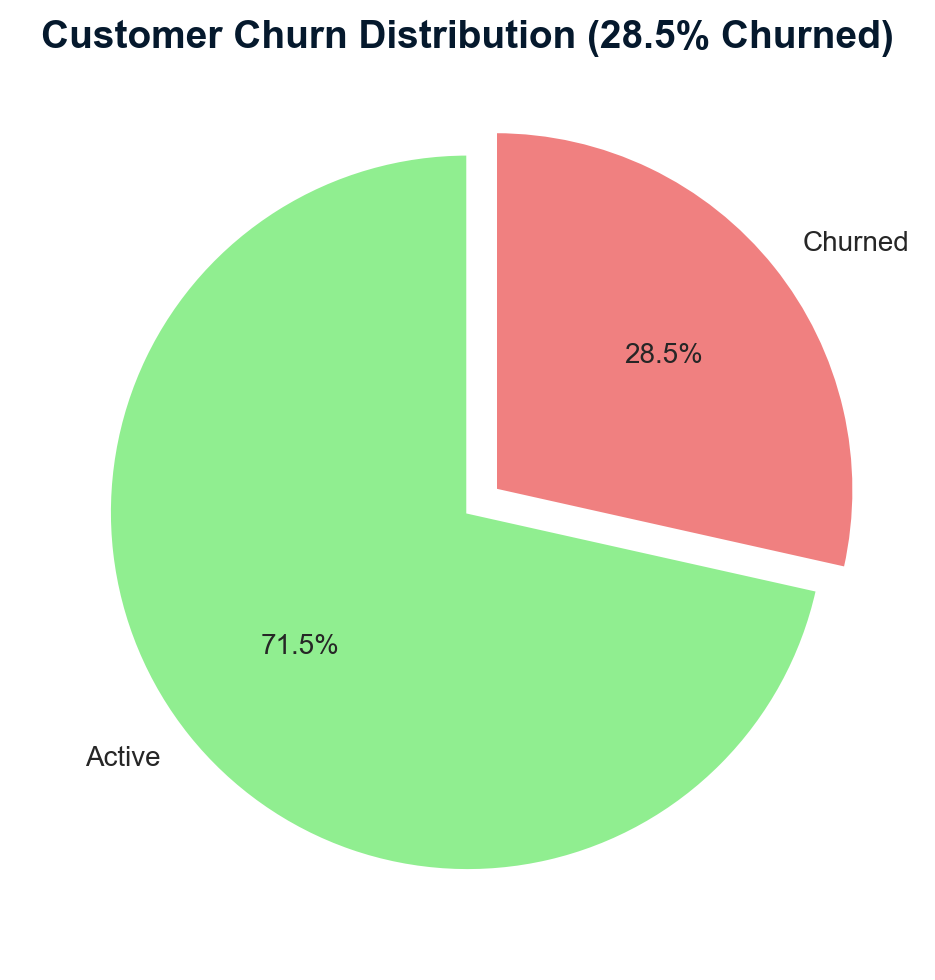

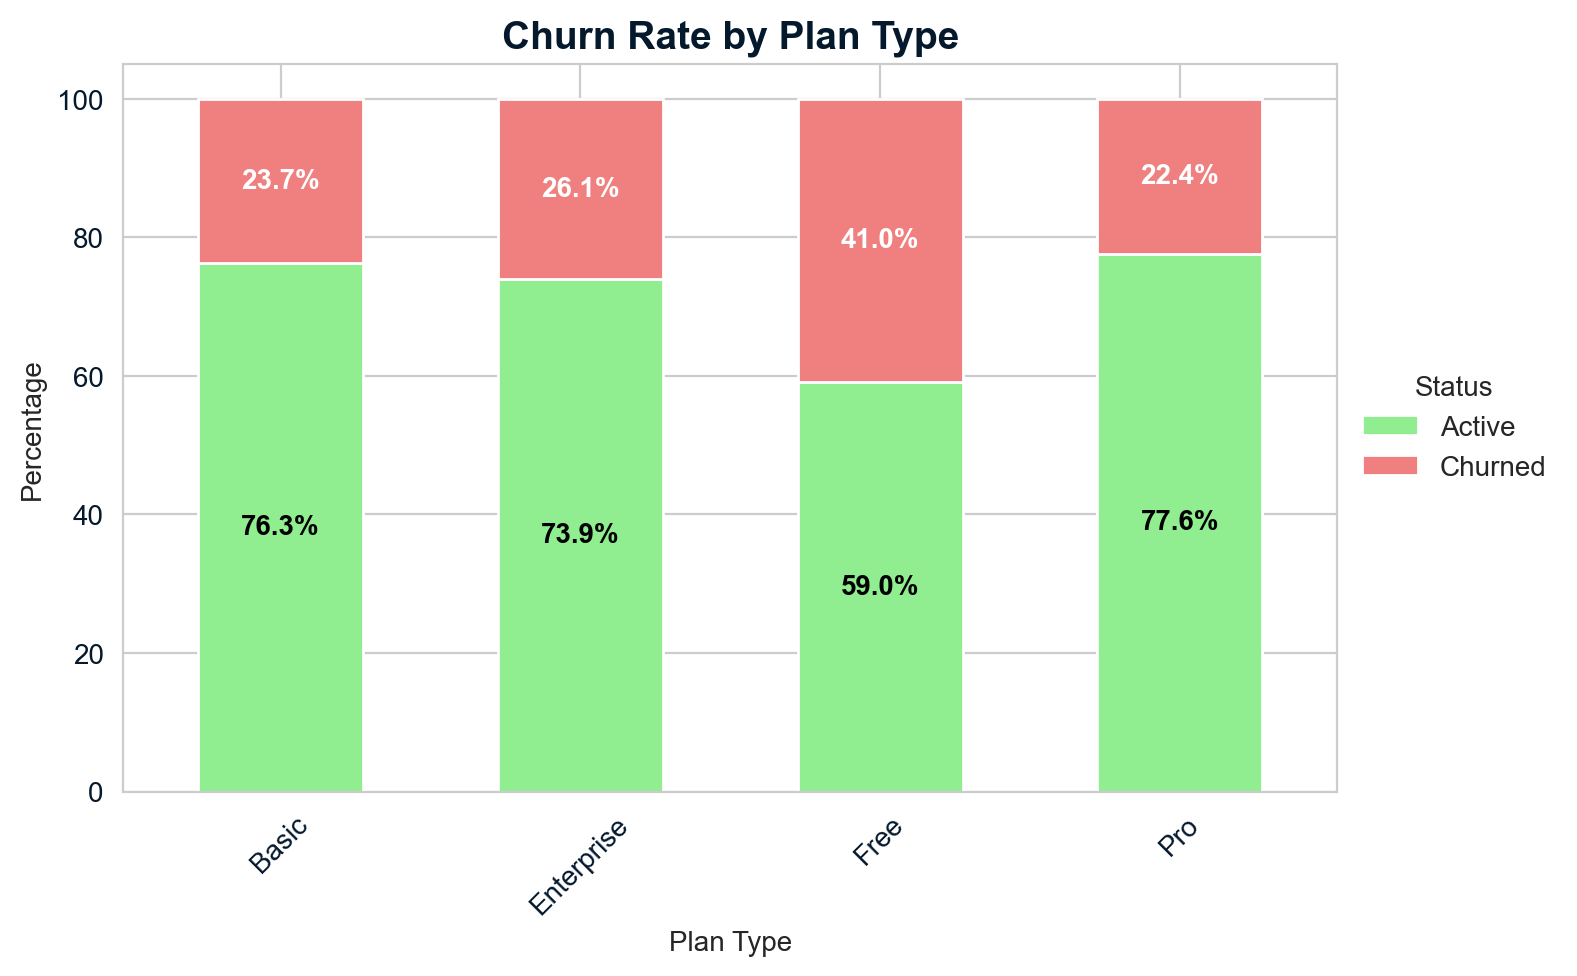

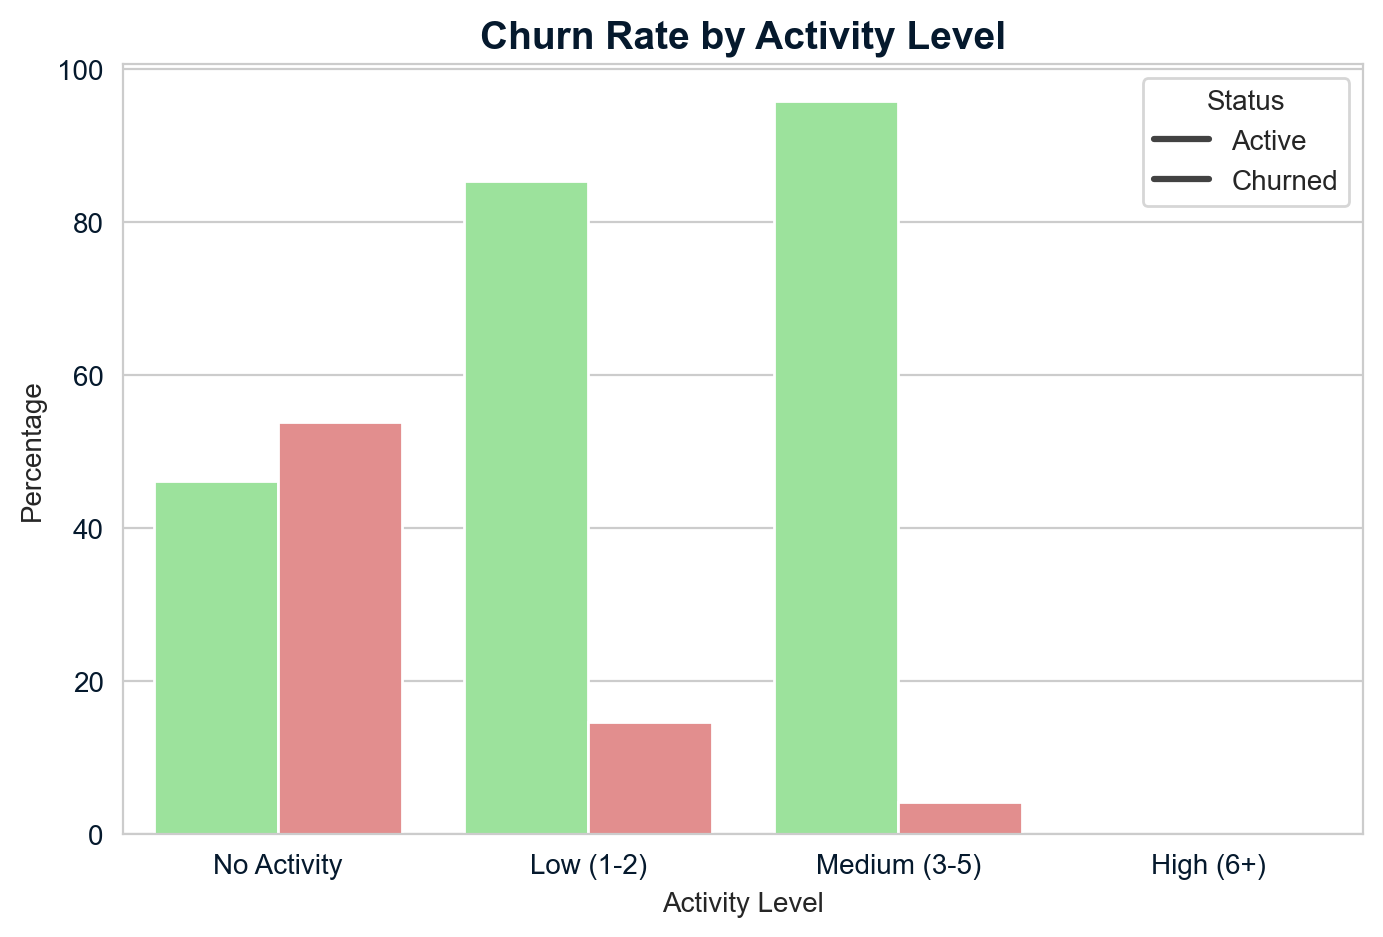

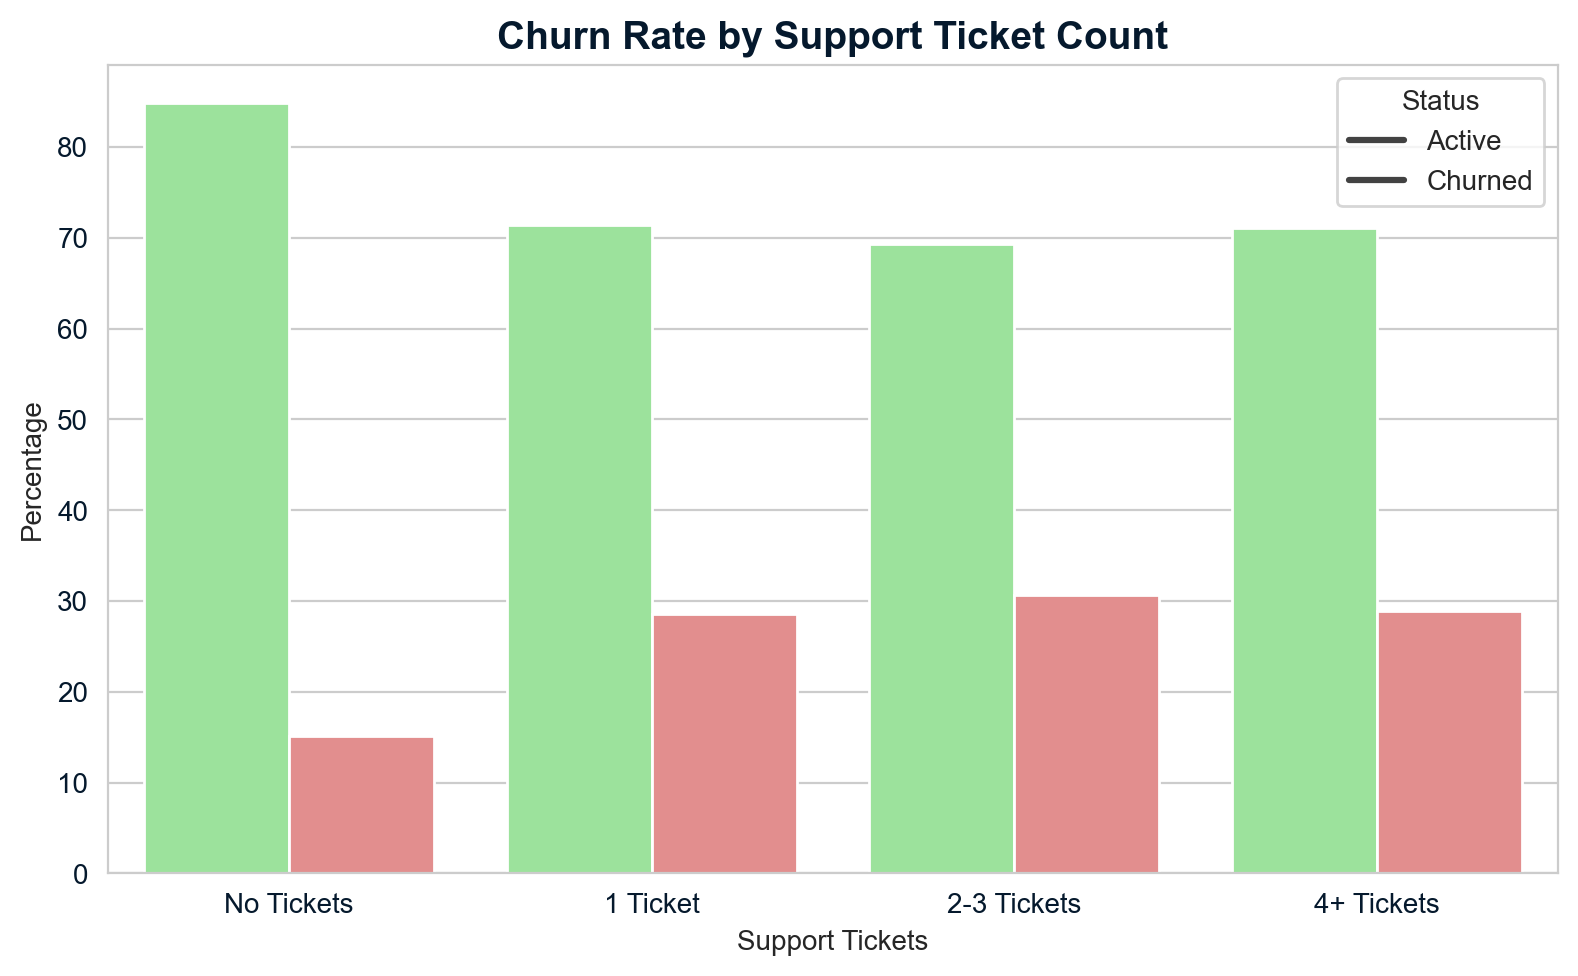

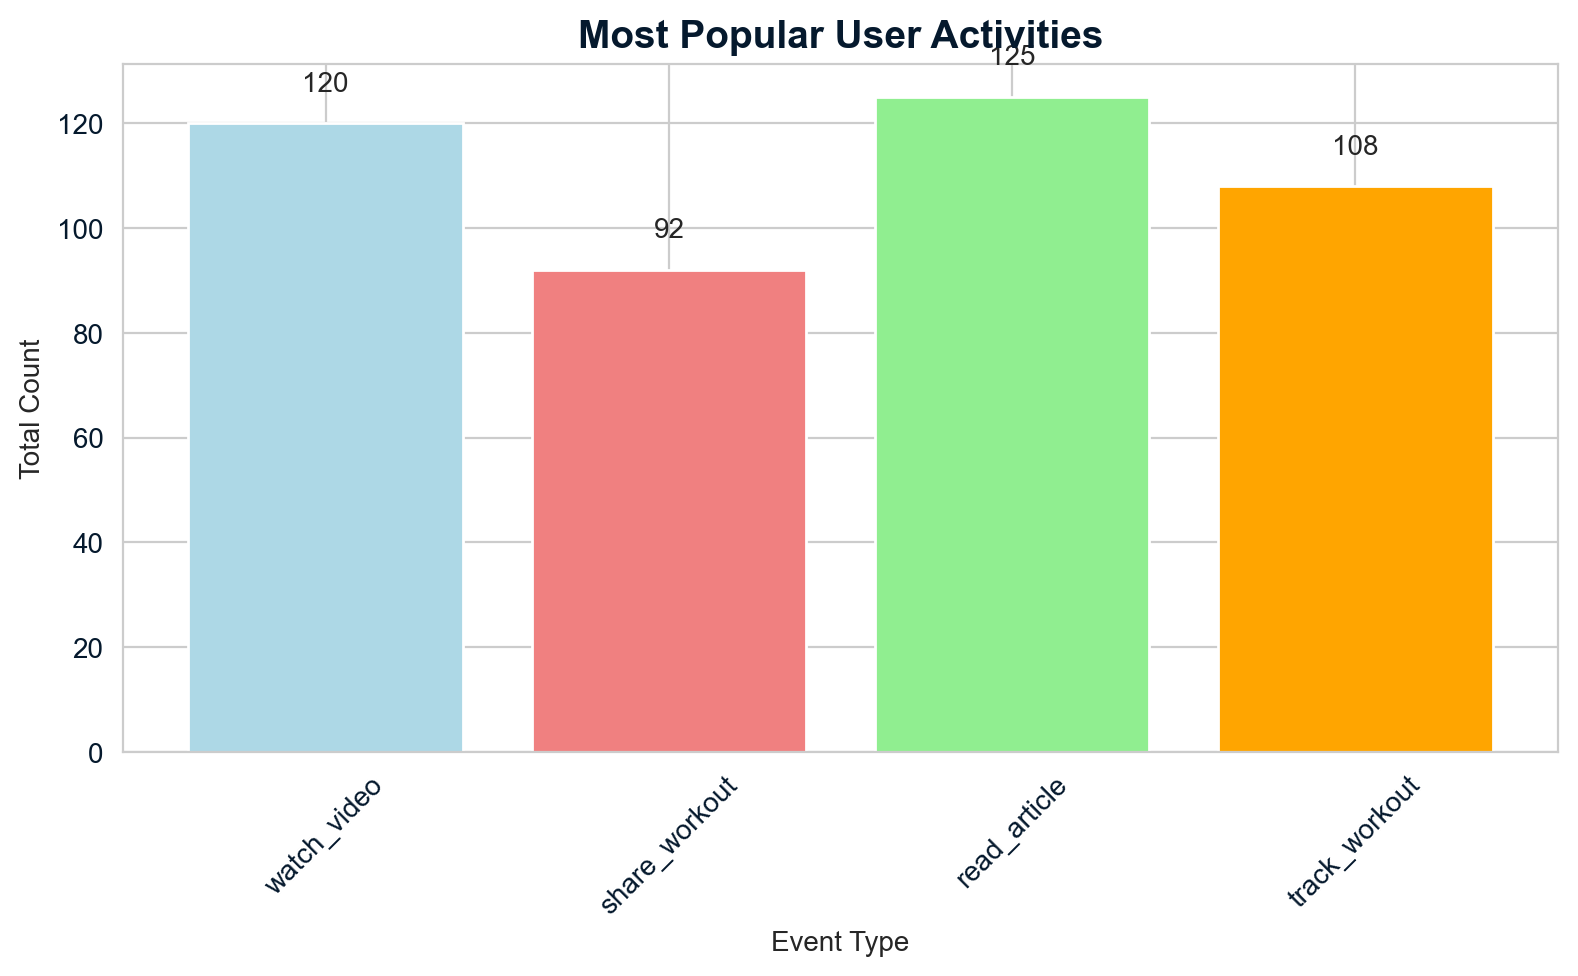

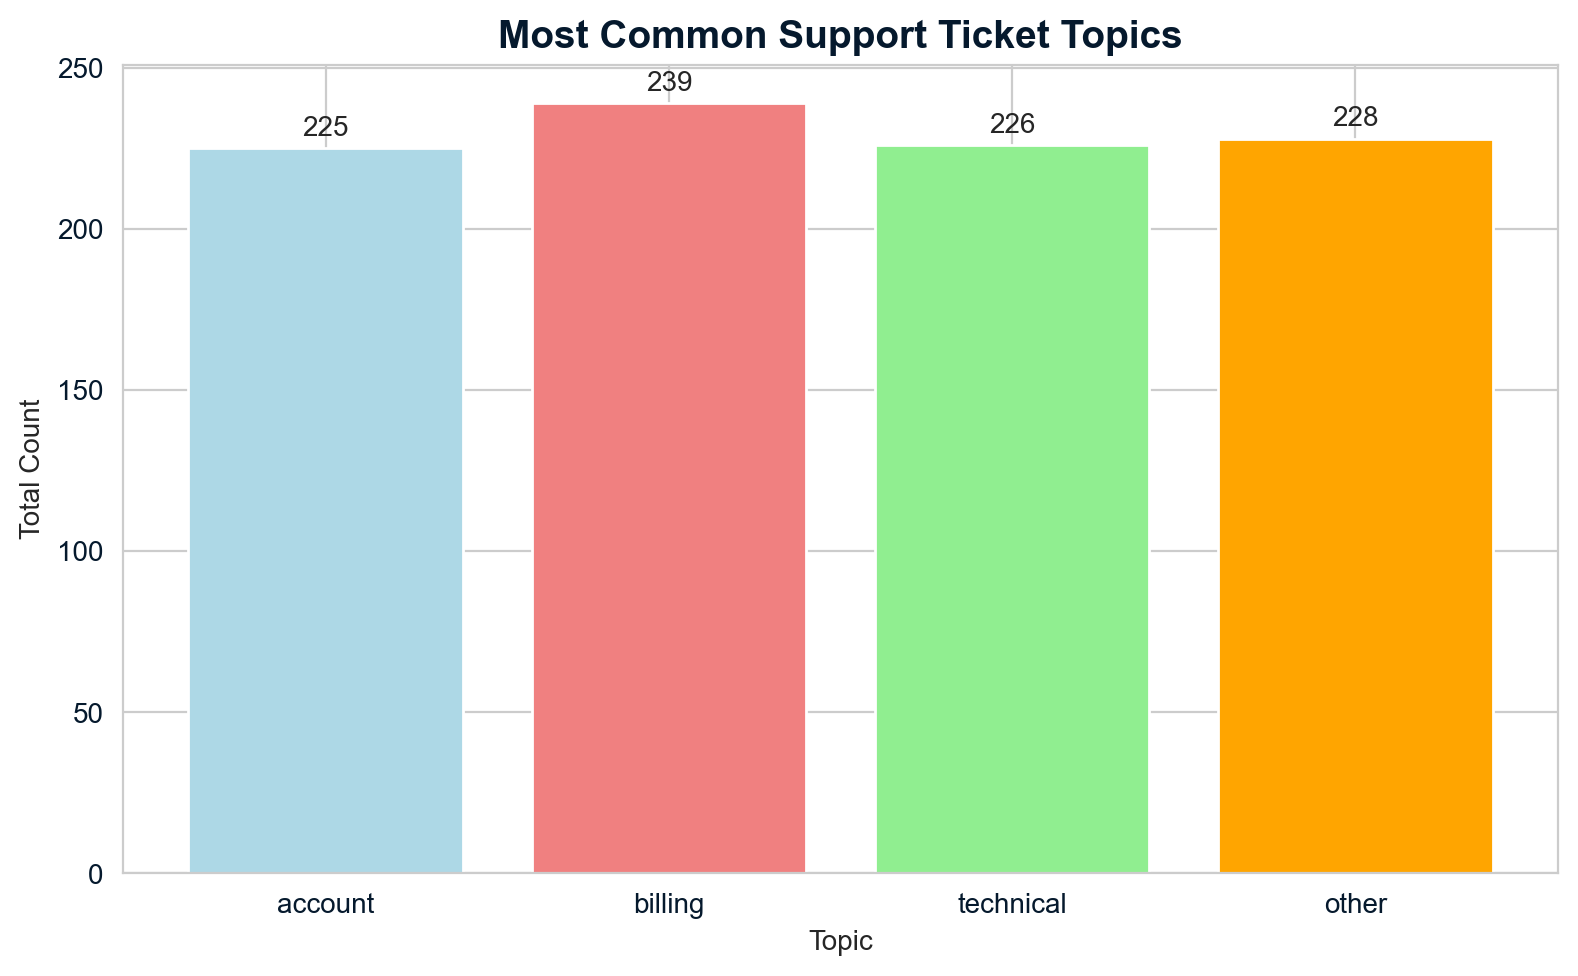

In [ ]:
# Set style for cleaner plots
sns.set_style("whitegrid")

# =========================
# 1) PIE CHART: Overall Churn Distribution
# =========================
churn_counts = user_data["is_churned"].value_counts()
labels = ["Active", "Churned"]
colors = ["lightgreen", "lightcoral"]

plt.figure(figsize=(6,5))
plt.pie(churn_counts, labels=labels, autopct="%1.1f%%", startangle=90, 
        colors=colors, explode=[0, 0.1])
plt.title("Customer Churn Distribution (28.5% Churned)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================
# 2) STACKED BAR CHART: Churn Rate by Plan Type 
# =========================
plan_churn = pd.crosstab(user_data["plan"], user_data["is_churned"], normalize="index") * 100
plan_churn.columns = ["Active", "Churned"]

# Plot stacked bar chart
ax = plan_churn.plot(kind='bar', stacked=True, color=['lightgreen', 'lightcoral'], 
                     edgecolor='white', figsize=(8, 5), width=0.55)

# Formatting titles and axes
plt.title("Churn Rate by Plan Type", fontsize=14, fontweight='bold')
plt.xlabel("Plan Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Status", frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))


# Add percentage labels inside the bars
for i, container in enumerate(ax.containers):
    
    label_color = 'white' if i == 1 else 'black'
    ax.bar_label(container, label_type='center', fmt='%.1f%%', 
                 fontweight='bold', color=label_color)

plt.tight_layout()
plt.show()

# =========================
# 3) GROUPED BAR CHART: Churn Rate by Activity Level
# =========================
# Create activity level categories
user_data["activity_level"] = pd.cut(
    user_data["total_activities"].fillna(0),
    bins=[-1, 0, 2, 5, 100],
    labels=["No Activity", "Low (1-2)", "Medium (3-5)", "High (6+)"]
)

activity_churn = (
    pd.crosstab(user_data["activity_level"], user_data["is_churned"], normalize="index") * 100
).reset_index()

activity_churn = activity_churn.melt(
    id_vars="activity_level",
    var_name="is_churned",
    value_name="percentage"
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=activity_churn,
    x="activity_level",
    y="percentage",
    hue="is_churned",
    palette=["lightgreen", "lightcoral"]
)
plt.title("Churn Rate by Activity Level", fontsize=14, fontweight='bold')
plt.xlabel("Activity Level")
plt.ylabel("Percentage")
plt.legend(title="Status", labels=["Active", "Churned"])

plt.show()

# =========================
# 4) GROUPED BAR CHART: Churn Rate by Support Tickets
# =========================
# Create ticket categories
user_data["ticket_category"] = pd.cut(
    user_data["total_tickets"].fillna(0),
    bins=[-1, 0, 1, 3, 100],
    labels=["No Tickets", "1 Ticket", "2-3 Tickets", "4+ Tickets"]
)

ticket_churn = (
    pd.crosstab(user_data["ticket_category"], user_data["is_churned"], normalize="index") * 100
).reset_index()

ticket_churn = ticket_churn.melt(
    id_vars="ticket_category",
    var_name="is_churned",
    value_name="percentage"
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=ticket_churn,
    x="ticket_category",
    y="percentage",
    hue="is_churned",
    palette=["lightgreen", "lightcoral"]
)
plt.title("Churn Rate by Support Ticket Count", fontsize=14, fontweight='bold')
plt.xlabel("Support Tickets")
plt.ylabel("Percentage")
plt.legend(title="Status", labels=["Active", "Churned"])
plt.tight_layout()
plt.show()

# =========================
# 5) BAR CHART: Most Common Event Types
# =========================
# Sum up all event counts
event_counts = user_data[['watch_video', 'share_workout', 'read_article', 'track_workout']].sum()

plt.figure(figsize=(8,5))
bars = plt.bar(event_counts.index, event_counts.values, 
               color=['lightblue', 'lightcoral', 'lightgreen', 'orange'])
plt.title("Most Popular User Activities", fontsize=14, fontweight='bold')
plt.xlabel("Event Type")
plt.ylabel("Total Count")
plt.xticks(rotation=45)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# =========================
# 6) BAR CHART: Most Common Support Topics
# =========================
# Sum up all topic counts
topic_columns = ['account', 'billing', 'technical', 'other']
topic_counts = user_data[topic_columns].sum()

plt.figure(figsize=(8,5))
bars = plt.bar(topic_counts.index, topic_counts.values, 
               color=['lightblue', 'lightcoral', 'lightgreen', 'orange'])
plt.title("Most Common Support Ticket Topics", fontsize=14, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Total Count")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



In [11]:
print("KEY METRICS ANALYSIS")
print("-" * 40)

# 1. Overall
churn_rate = user_data['is_churned'].mean() * 100
print(f"Overall Churn: {churn_rate:.1f}%")

# 2. By plan
print("\nChurn by Plan:")
for plan, rate in user_data.groupby("plan")["is_churned"].mean().mul(100).sort_values(ascending=False).items():
    print(f"  {plan}: {rate:.1f}%")

# 3. Activity
active = user_data[user_data["is_churned"] == 0]
churned = user_data[user_data["is_churned"] == 1]
print(f"\nActivity (avg):")
print(f"  Active: {active['total_activities'].mean():.1f}")
print(f"  Churned: {churned['total_activities'].mean():.1f}")

# 4. Tickets
print(f"\nUsers with Tickets:")
print(f"  Active: {(active['total_tickets']>0).mean()*100:.1f}%")
print(f"  Churned: {(churned['total_tickets']>0).mean()*100:.1f}%")

# 5. GDPR (if exists)
if 'has_gdpr_request' in user_data.columns:
    print(f"\nGDPR Request Churn:")
    no_gdpr = user_data[user_data['has_gdpr_request']==0]['is_churned'].mean()*100
    yes_gdpr = user_data[user_data['has_gdpr_request']==1]['is_churned'].mean()*100
    print(f"  No Request: {no_gdpr:.1f}%")
    print(f"  With Request: {yes_gdpr:.1f}%")

KEY METRICS ANALYSIS
----------------------------------------
Overall Churn: 28.5%

Churn by Plan:
  Free: 41.0%
  Enterprise: 26.1%
  Basic: 23.7%
  Pro: 22.4%

Activity (avg):
  Active: 1.4
  Churned: 0.4

Users with Tickets:
  Active: 90.2%
  Churned: 95.6%

GDPR Request Churn:
  No Request: 28.9%
  With Request: 37.1%


Step 7: Define Monitoring Metrics

In [12]:
# 1. Calculate Overall Churn Rate
overall_churn_rate = (account_info['churn_status'] == 'Y').mean() * 100

# 2. Calculate Churn by Plan
churn_by_plan = account_info.groupby('plan').apply(lambda x: (x['churn_status'] == 'Y').mean() * 100)

# 3. Create Active and Churned User subsets
active_users = user_data[user_data['is_churned'] == 0]
churned_users = user_data[user_data['is_churned'] == 1]

print("RECOMMENDED MONITORING METRICS")
print("=" * 50)

baseline_metrics = {
    'Overall Churn Rate': f"{overall_churn_rate:.1f}%",
    'Free Plan Churn Rate': f"{churn_by_plan.get('Free', 0):.1f}%",
    'Enterprise Plan Churn Rate': f"{churn_by_plan.get('Enterprise', 0):.1f}%",
    'Avg Activities (Active Users)': f"{active_users['total_activities'].mean():.1f}",
    'Avg Activities (Churned Users)': f"{churned_users['total_activities'].mean():.1f}",
    'Support Ticket Response Time Target': "< 8 hours",
    'Users with 0 Activities (30 days)': "To be monitored weekly"
}

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value}")

RECOMMENDED MONITORING METRICS
Overall Churn Rate: 28.5%
Free Plan Churn Rate: 41.0%
Enterprise Plan Churn Rate: 26.1%
Avg Activities (Active Users): 1.4
Avg Activities (Churned Users): 0.4
Support Ticket Response Time Target: < 8 hours
Users with 0 Activities (30 days): To be monitored weekly
